In [164]:
import numpy as np
from importlib import reload
import simulate_data as sim
reload(sim)
from gwas import gwas_linear, gwas_probit
from scipy.stats import norm

n, d = 5_000, 200
k = 10
corr = 0.7
rho = 0.7
snr_s = 4
snr_y = 1
pi_s = 0.1
pi_y = 0.05
p_sel = 0.3
rng = np.random.default_rng(42)

# LD matrix
R = sim.simulate_block_correlation_matrix(d, k, corr)

X = sim.simulate_design_matrix(n, R, intercept = False, rng = rng)

beta_s = sim.beta_s(d, R, pi_s, snr_s, rng)
beta_y, sigma2_y = sim.beta_heckman(d, R, pi_y, snr_y, rng)

s, y, s_star, y_star =  sim.heckman_outcome(X, beta_s, beta_y, sigma2_y, p_sel, rho, snr_s, rng = rng)

b_s = gwas_probit(X, s)[0] / np.sqrt(len(s))
b_y = gwas_linear(X, y)[0] / np.sqrt(s.sum()) #we assume Var(y) = 1

In [188]:
from scipy.stats import norm
n_case = s.sum()
n_control = n - n_case
n_eff = 4 / (1 / n_case + 1 / n_control)

#K = p_sel
#t = norm.isf(K)              # liability threshold
#z = norm.pdf(t)               # N(0,1) density at the threshold
latent_sd_correction = np.sqrt(1 + snr_s)

# --- raw z-score from probit GWAS ---
z_s = gwas_probit(X, s)[0]

# --- corrected beta on the liability scale ---
b_s_corrected = z_s / np.sqrt(n_eff) * latent_sd_correction

# sanity check against the true beta_s used to generate the data
print("correlation:", np.corrcoef(b_s_corrected, beta_s)[0, 1])
print("slope:", np.polyfit(beta_s, b_s_corrected, 1)[0])  # should be ~1

correlation: 0.4511181507771043
slope: 0.9089390941591201


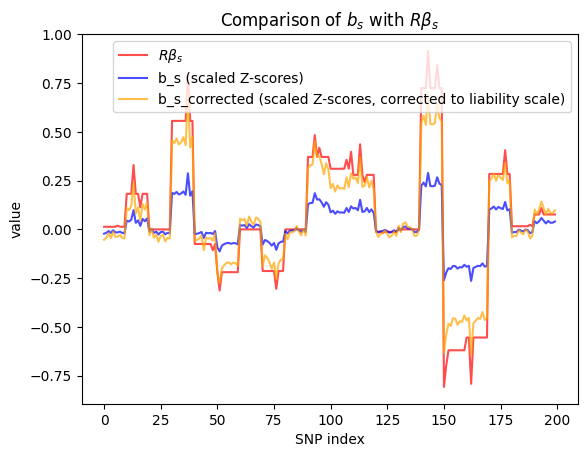

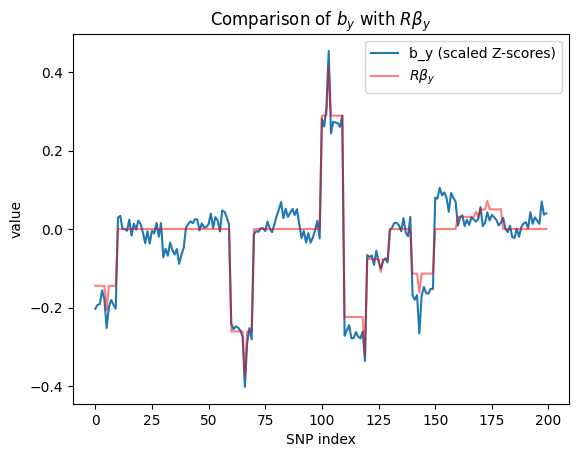

In [187]:
import matplotlib.pyplot as plt

R_hat = np.corrcoef(X, rowvar=False)
plt.plot(R @ beta_s , color="red", alpha=0.7, label=r"$R \beta_s$")
plt.plot(b_s, color = "blue", alpha=0.7,label="b_s (scaled Z-scores)")
plt.plot(b_s_corrected, color = "orange", alpha=0.7, label = "b_s_corrected (scaled Z-scores, corrected to liability scale)")
plt.legend()
plt.xlabel("SNP index")
plt.ylabel("value")
plt.title(r"Comparison of $b_s$ with $R\beta_s$")
plt.show()


plt.plot(b_y, label="b_y (scaled Z-scores)")
plt.plot(R @ beta_y, color="red", alpha=0.5, label=r"$R \beta_y$")
plt.legend()
plt.xlabel("SNP index")
plt.ylabel("value")
plt.title(r"Comparison of $b_y$ with $R\beta_y$")
plt.show()

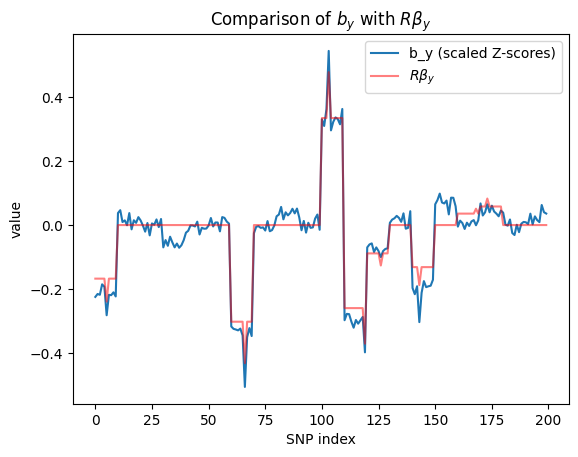

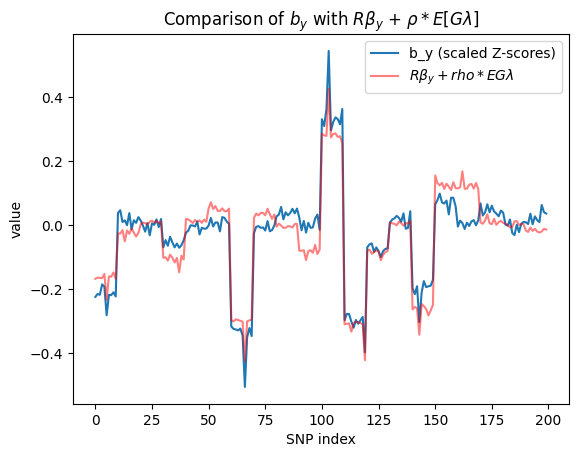

In [102]:
import numpy as np
from scipy.stats import norm

def inverse_mills_ratio(eta):
    log_lambda = norm.logpdf(eta) - norm.logcdf(eta)
    return np.exp(log_lambda)

eta = X @ beta_s
lam_eta = inverse_mills_ratio(eta)                  # shape (n,)
E_G_lambda = (X * lam_eta[:, None]).mean(axis=0)    # shape (d,)

plt.plot(b_y, label="b_y (scaled Z-scores)")
plt.plot(R @ beta_y, color="red", alpha=0.5, label=r"$R \beta_y$")
plt.legend()
plt.xlabel("SNP index")
plt.ylabel("value")
plt.title(r"Comparison of $b_y$ with $R\beta_y$")
plt.show()


plt.plot(b_y, label="b_y (scaled Z-scores)")
plt.plot(R @ beta_y + rho*E_G_lambda , color="red", alpha=0.5, label=r"$R \beta_y + rho*E G \lambda$")
plt.legend()
plt.xlabel("SNP index")
plt.ylabel("value")
plt.title(r"Comparison of $b_y$ with $R\beta_y$ + $\rho*E[G \lambda]$")
plt.show()

mu_eta = -0.5244005127080409
sigma2_eta = 0.8000000000000002
sigma_eta = 0.894427190999916
sigma2_s = 0.19999999999999996
sigma_s = 0.44721359549995787
Var(s*) = 1.0
lambda = 1.1589753806669127
q = 0.7354566491542893
beta_s^T R beta_y = -0.05956177357866377
rho sigma_s sigma_y = 0.18073922282301277
Cov(y*, s*) = 0.121177449244349
k = 0.08912076077431288


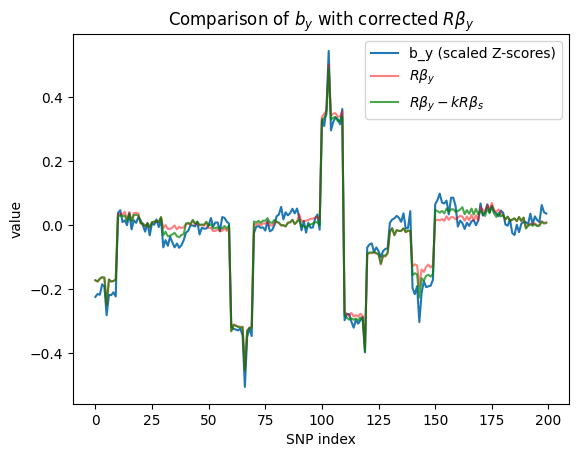

In [108]:
from scipy.stats import norm

mu_eta = norm.ppf(p_sel)

sigma2_eta = beta_s.T @ R @ beta_s
sigma_eta = np.sqrt(sigma2_eta)

sigma_s = np.sqrt(sigma2_s)
sigma_y = np.sqrt(sigma2_y)

# Inverse Mills ratio
lambda_sel = norm.pdf(mu_eta) / p_sel

# Selection-induced truncation factor
q = mu_eta * lambda_sel + lambda_sel**2

# Cov(beta_s^T G, beta_y^T G)
genetic_overlap = beta_s.T @ R @ beta_y

# Cov(y*, s*)
cov_y_selection = (
    genetic_overlap
    + rho * sigma_s * sigma_y
)

# Correct k
k_corr = q * cov_y_selection


b_y_exxpected = R_hat @ beta_y - k_corr * R_hat @ beta_s


print("mu_eta =", mu_eta)
print("sigma2_eta =", sigma2_eta)
print("sigma_eta =", sigma_eta)
print("sigma2_s =", sigma2_s)
print("sigma_s =", sigma_s)
print("Var(s*) =", sigma2_eta + sigma2_s)

print("lambda =", lambda_sel)
print("q =", q)
print("beta_s^T R beta_y =", genetic_overlap)
print("rho sigma_s sigma_y =", rho * sigma_s * sigma_y)
print("Cov(y*, s*) =", cov_y_selection)
print("k =", k_corr)

plt.plot(
    b_y,
    label="b_y (scaled Z-scores)"
)

plt.plot(
    R_hat @ beta_y,
    color="red",
    alpha=0.5,
    label=r"$R\beta_y$"
)

plt.plot(
    R_hat @ beta_y - k_corr * R_hat @ beta_s,
    color="green",
    alpha=0.7,
    label=r"$R\beta_y-kR\beta_s$"
)

plt.legend()
plt.xlabel("SNP index")
plt.ylabel("value")
plt.title(r"Comparison of $b_y$ with corrected $R\beta_y$")
plt.show()

uncorrected R@beta_y     MSE=0.00106849  MAE=0.0260047  corr=0.9771  R2=0.9512
approx1 (closed-form k)  MSE=0.000742842  MAE=0.0226377  corr=0.9841  R2=0.9661
approx2 (Monte Carlo IMR) MSE=0.00126401  MAE=0.0277394  corr=0.9718  R2=0.9423


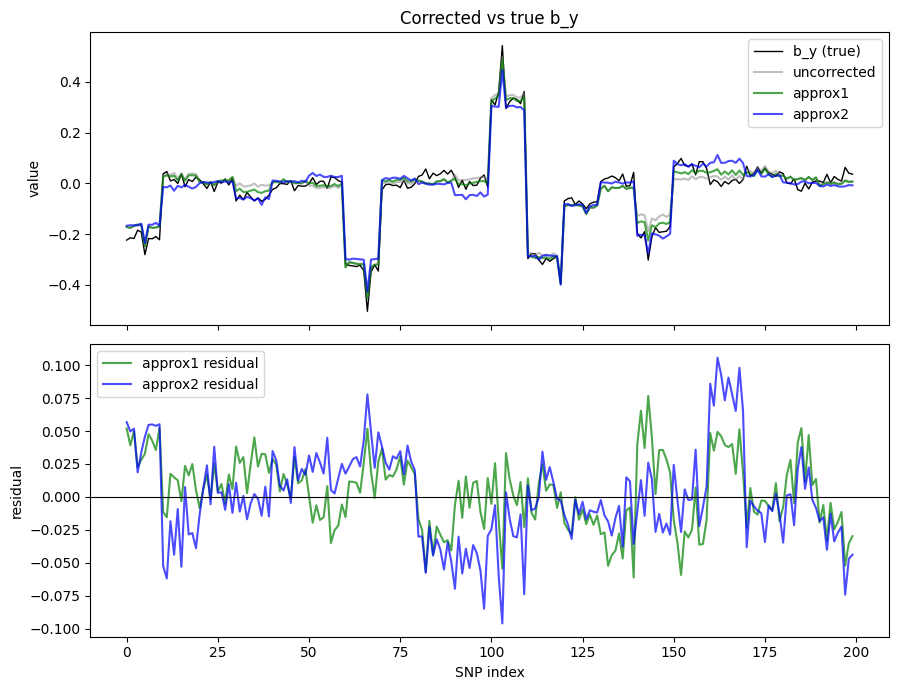

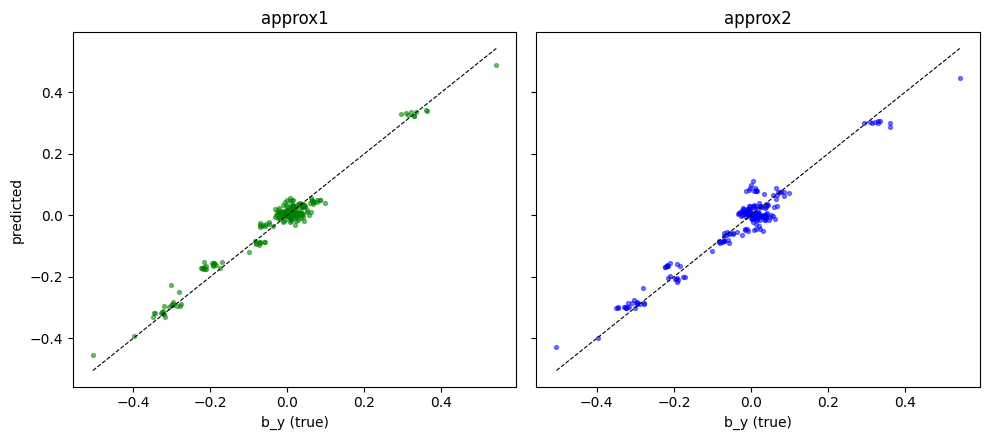

In [107]:
import numpy as np
from scipy.stats import norm, pearsonr

# ============================================================
# Approximation 1: closed-form correction from summary statistics
# ============================================================
mu_eta = norm.ppf(p_sel)
sigma2_eta = beta_s.T @ R @ beta_s
lambda_sel = norm.pdf(mu_eta) / p_sel
q = mu_eta * lambda_sel + lambda_sel**2  # leading-order approx of E[eta*phi(eta)]
genetic_overlap = beta_s.T @ R @ beta_y
cov_y_selection = genetic_overlap + rho * sigma_s * sigma_y
k_corr = q * cov_y_selection
b_y_approx1 = R_hat @ beta_y - k_corr * R_hat @ beta_s

# ============================================================
# Approximation 2: individual-level Monte Carlo correction (inverse Mills ratio)
# ============================================================
def inverse_mills_ratio(eta):
    # log-space for numerical stability
    log_lambda = norm.logpdf(eta) - norm.logcdf(eta)
    return np.exp(log_lambda)

eta_i = X @ beta_s
lam_eta = inverse_mills_ratio(eta_i)
E_G_lambda = (X * lam_eta[:, None]).mean(axis=0)
b_y_approx2 = R @ beta_y + rho * sigma_y * E_G_lambda  # sigma_y added for consistency

# ============================================================
# Ground truth and uncorrected baseline
# ============================================================
b_y_true = b_y
b_y_uncorrected = R_hat @ beta_y

# ============================================================
# Metrics
# ============================================================
def eval_metrics(pred, true, name):
    resid = pred - true
    mse = np.mean(resid**2)
    mae = np.mean(np.abs(resid))
    corr, _ = pearsonr(pred, true)
    ss_res = np.sum(resid**2)
    ss_tot = np.sum((true - true.mean())**2)
    r2 = 1 - ss_res / ss_tot
    print(f"{name:24s} MSE={mse:.6g}  MAE={mae:.6g}  corr={corr:.4f}  R2={r2:.4f}")
    return dict(name=name, mse=mse, mae=mae, corr=corr, r2=r2)

results = [
    eval_metrics(b_y_uncorrected, b_y_true, "uncorrected R@beta_y"),
    eval_metrics(b_y_approx1,     b_y_true, "approx1 (closed-form k)"),
    eval_metrics(b_y_approx2,     b_y_true, "approx2 (Monte Carlo IMR)"),
]

# ============================================================
# Visual comparison: trajectories + residuals
# ============================================================
fig, axes = plt.subplots(2, 1, figsize=(9, 7), sharex=True)

axes[0].plot(b_y_true, label="b_y (true)", color="black", lw=1)
axes[0].plot(b_y_uncorrected, label="uncorrected", color="gray", alpha=0.5)
axes[0].plot(b_y_approx1, label="approx1", color="green", alpha=0.7)
axes[0].plot(b_y_approx2, label="approx2", color="blue", alpha=0.7)
axes[0].legend()
axes[0].set_ylabel("value")
axes[0].set_title("Corrected vs true b_y")

axes[1].plot(b_y_approx1 - b_y_true, label="approx1 residual", color="green", alpha=0.7)
axes[1].plot(b_y_approx2 - b_y_true, label="approx2 residual", color="blue", alpha=0.7)
axes[1].axhline(0, color="black", lw=0.8)
axes[1].legend()
axes[1].set_xlabel("SNP index")
axes[1].set_ylabel("residual")

plt.tight_layout()
plt.show()

# ============================================================
# Scatter: predicted vs true, per approximation
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), sharex=True, sharey=True)
for ax, pred, name, color in zip(
    axes, [b_y_approx1, b_y_approx2], ["approx1", "approx2"], ["green", "blue"]
):
    ax.scatter(b_y_true, pred, s=8, alpha=0.5, color=color)
    lims = [min(b_y_true.min(), pred.min()), max(b_y_true.max(), pred.max())]
    ax.plot(lims, lims, "k--", lw=0.8)
    ax.set_xlabel("b_y (true)")
    ax.set_title(name)
axes[0].set_ylabel("predicted")
plt.tight_layout()
plt.show()